# Displacement dependent pressure loads: Schweizerhof and Ramm (1984)

K. Schweizerhof and E. Ramm, *Displacement dependent pressure loads in nonlinear finite element analyses*, Computers & Structures 18 (1984) 1099-1114.

The paper classifies pressure loads (Fig. 3): constant directional or follower, attached to the body (a function of the initial coordinates) or to the space. The follower pressure of panels, `add_pressure_load(..., follower=True)`, with `p(x, y)` a function of the undeformed coordinates, is the body-attached follower load, case 3 of Fig. 3. The examples reproduced here:

- Table 2: when the load stiffness matrix is symmetric;
- Section 6.1, Table 3: a circular ring under uniform pressure, $p_{cr} = k EI/R^3$, for the hydrostatic (follower), constant directional and centrally directed loads;
- Section 6.4, Table 4 and Fig. 13: cylindrical cantilever shells under uniform pressure, whose free edge makes the load stiffness unsymmetric, and cylinders hinged at both ends, $p_{cr} = k E t^3/(12(1 - \mu^2) R^3)$;

with the data in `tests/tests_shell/test_follower_pressure_validation.py`. The examples of Sections 6.2 (a ring under a non-uniform pressure, with displacements up to $0.8 R$) and 6.3 (Beck's column, a single tangential force) are outside the moderate-rotation shell models of panels and the scope of the pressure loads.

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import follower_utils as fu
from follower_utils import val, fmt, pct, markdown_table

# True runs panels again, otherwise the results saved in RESULTS are loaded
RERUN = False
RESULTS = 'results'

from structsolve import solve, lb

## Table 2: symmetry of the load stiffness matrix

For the first-order area vector of panels the skew part of the load stiffness is a boundary integral over the loaded region plus a term of the gradient of the pressure, see `theory/shells/follower_pressure/follower_pressure.md`, which is Table 2 of the paper for body-attached loads: symmetric (S) for a uniform pressure and specific boundary conditions, either the normal displacement or $w$ zero on each edge, nonsymmetric (N) for a non-uniform pressure or arbitrary boundary conditions. The relative skew part $\|K - K^T\|/\|K\|$ of `calc_kCfollower` for the sector of the hinged shell 1 below and of the cantilever B1, with a uniform and a non-uniform pressure:

In [2]:
rows = []
for bc in ('hinged', 'B1'):
    for label, p in (('uniform', -1.), ('non-uniform, $p = -(1 + x/L)$', lambda x, y: -(1 + x/600.))):
        s = val.schweizerhof_sector(600., 100., 1., 3, bc)
        s.add_pressure_load(p, follower=True)
        K = s.calc_kCfollower().toarray()
        rows.append([bc, label, '%.1e' % (np.linalg.norm(K - K.T)/np.linalg.norm(K))])
display(Markdown(markdown_table(['boundary conditions', 'pressure', '$\\|K - K^T\\|/\\|K\\|$'], rows)))

| boundary conditions | pressure | $\|K - K^T\|/\|K\|$ |
|---|---|---|
| hinged | uniform | 9.0e-15 |
| hinged | non-uniform, $p = -(1 + x/L)$ | 2.5e-01 |
| B1 | uniform | 5.2e-01 |
| B1 | non-uniform, $p = -(1 + x/L)$ | 4.8e-01 |

## Table 3: circular ring under uniform pressure

Ring of Fig. 7, $R = 120$ cm, $h = b = 1$ cm, $EI = 45880$ N cm$^2$, modelled as a quarter ring in plane strain with $\nu = 0$, such that $D b = EI$, see `val.ring_shell`. The centrally directed load stiffness is integrated independently, `val.central_load_stiffness`.

In [3]:
EI = 45880.
R, h = 120., 1.
E = 12*EI/h**3
TABLE3 = {'follower': (3.003, 3.000), 'dead': (4.004, 4.000), 'central': (4.428, 4.500)}
names = {'follower': 'hydrostatic', 'dead': 'constant directional', 'central': 'centrally directed'}
rows = []
for load, (fe, analytic) in TABLE3.items():
    s = val.ring_shell('cylshell_clpt_sanders', R, [0.], [h], [(E, E, 0., E/2, E/2, E/2)])
    k = val.ring_buckling_pressure(s, load)*R**3/EI
    rows.append([names[load], '%.3f' % fe, '%.3f' % analytic, '%.4f (%+.2f%%)' % (k, pct(k, analytic))])
display(Markdown(markdown_table(['load', 'FE, 12 elements (paper)', 'analytical, Pflüger (paper)', 'panels'], rows)))

| load | FE, 12 elements (paper) | analytical, Pflüger (paper) | panels |
|---|---|---|---|
| hydrostatic | 3.003 | 3.000 | 3.0000 (-0.00%) |
| constant directional | 4.004 | 4.000 | 4.0000 (+0.00%) |
| centrally directed | 4.428 | 4.500 | 4.5000 (-0.00%) |

## Table 4: cylindrical shells under uniform pressure

Three shells, $E = 2.1 \times 10^6$, $\mu = 0.3$, $R = 100$, with $L/R$ and $R/t$ of the table, modelled as a half wave of the circumference, $b = \pi R/n$, with symmetry planes at the straight edges, `val.schweizerhof_sector`, and a lateral pressure, the prestress coming from a linear static analysis:

- hinged at both ends, $v = w = 0$, $u$ free (one point fixed), no warping restraint;
- cantilever with the lower end hinged and the upper end free: B1, warping completely restrained, $u = v = w = 0$; B2, warping partially restrained, $v = w = 0$ with $u$ fixed at one point only; clamped, B1 with $w_{,x} = 0$, compared with the references [36] and [15] of the paper.

$k_c$ is the constant directional load, $k_f$ the follower load. For the cantilevers the paper symmetrizes the load stiffness in three ways, Eqs. (63)-(65), with nearly the same results, whereas panels solves the unsymmetric eigenvalue problem. The circumferential wave number $n$ is the one with the lowest load among $n - 1$, $n$, $n + 1$ around that of the paper, except for B2, for which the paper adopts the sector angle, i.e. the $n$, of B1: the lowest load of B2 among $n - 1$, $n$, $n + 1$ is given in an additional row.

In [4]:
# shell, L/R, R/t, n of the paper, (k_c, k_f) hinged, B1, B2 (Eq. 63), clamped refs [36], [15]
TABLE4 = [(1, 6., 100., (4, 3), (18.76, 17.62), (10.89, 9.70), (9.11, 8.10), (9.85, 10.51)),
          (2, 3., 100., (5, 4), (35.25, 34.28), (20.85, 19.58), (16.43, 15.42), (19.97, 21.01)),
          (3, 3., 500., (7, 6), (78.55, 77.48), (45.83, None), (36.48, 35.48), (None, 46.98))]


def clamped_sector(L, R, t, n):
    s = val.schweizerhof_sector(L, R, t, n, 'B1')
    s.x1wr = 0.
    s._rebuild()
    return s


def k_min(build, ns, follower, symmetric_part=False):
    ks = {}
    for n in ns:
        s = build(n)
        if symmetric_part:
            ks[n] = k_symmetric_part(s)
        else:
            ks[n] = val.schweizerhof_k(s, follower)
    n = min(ks, key=ks.get)
    return n, ks[n]


def k_symmetric_part(s):
    r"""k_f with the symmetric part of the load stiffness only, Eq. (63)"""
    s.clear_loads()
    s.add_pressure_load(-1., cte=False, follower=True)
    k0 = s.calc_kC()
    if s.x1u == 1.:
        k0 = k0 + s.calc_stiffness_point_constraint(0., s.b/2, u=True, v=False, w=False,
                                                    kuvw=1e3*val.SCHWEIZERHOF_E*s.plyt)
    c0 = solve(k0, s.calc_fext(), silent=True)
    kF = s.calc_kCfollower()
    K = s.calc_kG(c=c0) + 0.5*(kF + kF.T)
    ev = lb(k0, K, silent=True, num_eigvalues=4, symmetric=True)[0]
    D = val.SCHWEIZERHOF_E*s.plyt**3/(12*(1 - val.SCHWEIZERHOF_NU**2))
    return float(ev[0])*s.r**3/D


def compute():
    res = {}
    R = 100.
    for shell, LR, Rt, (n_h, n_c), *_ in TABLE4:
        L, t = LR*R, R/Rt
        for bc, n0 in (('hinged', n_h), ('B1', n_c), ('B2', n_c), ('clamped', n_c)):
            ns = (n0 - 1, n0, n0 + 1)
            if bc == 'clamped':
                build = lambda n: clamped_sector(L, R, t, n)
            else:
                build = lambda n, bc=bc: val.schweizerhof_sector(L, R, t, n, bc)
            # the paper adopts for B2 the sector angle of B1, i.e. its n
            nsel = (n0,) if bc == 'B2' else ns
            for follower in (False, True):
                res['%d %s %s' % (shell, bc, 'f' if follower else 'c')] = k_min(build, nsel, follower)
                if bc == 'B2':
                    res['%d B2 %s lowest' % (shell, 'f' if follower else 'c')] = k_min(build, ns, follower)
            if bc != 'hinged':
                res['%d %s fsym' % (shell, bc)] = k_min(build, nsel, True, symmetric_part=True)
    return res


res = fu.run_or_load(os.path.join(RESULTS, 'schweizerhof1984_table4.json'), compute, rerun=RERUN)

In [5]:
def cell(key, ref):
    n, k = res[key]
    return '%.2f (n = %d%s)' % (k, n, '' if ref is None else ', %+.1f%%' % pct(k, ref))


rows = []
for shell, LR, Rt, ns, hinged, b1, b2, clamped in TABLE4:
    rows.append(['%d, L/R = %g, R/t = %g' % (shell, LR, Rt), 'hinged both ends',
                 fmt(hinged[0], 2), cell('%d hinged c' % shell, hinged[0]),
                 fmt(hinged[1], 2), cell('%d hinged f' % shell, hinged[1]), '-'])
    for bc, ref in (('B1', b1), ('B2', b2)):
        rows.append(['', 'cantilever %s' % bc, fmt(ref[0], 2), cell('%d %s c' % (shell, bc), ref[0]),
                     fmt(ref[1], 2), cell('%d %s f' % (shell, bc), ref[1]),
                     cell('%d %s fsym' % (shell, bc), ref[1])])
    rows.append(['', 'cantilever B2, lowest $n$', '-', cell('%d B2 c lowest' % shell, None), '-',
                 cell('%d B2 f lowest' % shell, None), '-'])
    n, k = res['%d clamped f' % shell]
    vs = ', '.join('%+.1f%% vs [%s]' % (pct(k, r), ref) for r, ref in zip(clamped, (36, 15)) if r is not None)
    rows.append(['', 'cantilever clamped', '-', cell('%d clamped c' % shell, None),
                 '%s [36], %s [15]' % (fmt(clamped[0], 2), fmt(clamped[1], 2)),
                 '%.2f (n = %d, %s)' % (k, n, vs), cell('%d clamped fsym' % shell, None)])
display(Markdown(markdown_table(['shell', 'boundary conditions', '$k_c$ paper', '$k_c$ panels',
                                 '$k_f$ paper', '$k_f$ panels (unsymmetric)', '$k_f$ panels, symmetric part'], rows)))

| shell | boundary conditions | $k_c$ paper | $k_c$ panels | $k_f$ paper | $k_f$ panels (unsymmetric) | $k_f$ panels, symmetric part |
|---|---|---|---|---|---|---|
| 1, L/R = 6, R/t = 100 | hinged both ends | 18.76 | 18.77 (n = 4, +0.1%) | 17.62 | 17.62 (n = 4, +0.0%) | - |
|  | cantilever B1 | 10.89 | 10.88 (n = 3, -0.1%) | 9.70 | 9.68 (n = 3, -0.2%) | 9.68 (n = 3, -0.2%) |
|  | cantilever B2 | 9.11 | 9.10 (n = 3, -0.2%) | 8.10 | 8.09 (n = 3, -0.1%) | 8.09 (n = 3, -0.1%) |
|  | cantilever B2, lowest $n$ | - | 4.11 (n = 2) | - | 3.10 (n = 2) | - |
|  | cantilever clamped | - | 10.89 (n = 3) | 9.85 [36], 10.51 [15] | 9.70 (n = 3, -1.6% vs [36], -7.8% vs [15]) | 9.70 (n = 3) |
| 2, L/R = 3, R/t = 100 | hinged both ends | 35.25 | 35.64 (n = 5, +1.1%) | 34.28 | 34.30 (n = 5, +0.1%) | - |
|  | cantilever B1 | 20.85 | 20.77 (n = 4, -0.4%) | 19.58 | 19.51 (n = 4, -0.4%) | 19.51 (n = 4, -0.4%) |
|  | cantilever B2 | 16.43 | 16.37 (n = 4, -0.4%) | 15.42 | 15.37 (n = 4, -0.3%) | 15.37 (n = 4, -0.3%) |
|  | cantilever B2, lowest $n$ | - | 9.41 (n = 3) | - | 8.41 (n = 3) | - |
|  | cantilever clamped | - | 20.81 (n = 4) | 19.97 [36], 21.01 [15] | 19.55 (n = 4, -2.1% vs [36], -7.0% vs [15]) | 19.55 (n = 4) |
| 3, L/R = 3, R/t = 500 | hinged both ends | 78.55 | 78.72 (n = 8, +0.2%) | 77.48 | 77.50 (n = 7, +0.0%) | - |
|  | cantilever B1 | 45.83 | 45.67 (n = 6, -0.3%) | - | 44.42 (n = 6) | 44.42 (n = 6) |
|  | cantilever B2 | 36.48 | 36.40 (n = 6, -0.2%) | 35.48 | 35.40 (n = 6, -0.2%) | 35.40 (n = 6, -0.2%) |
|  | cantilever B2, lowest $n$ | - | 25.42 (n = 5) | - | 24.42 (n = 5) | - |
|  | cantilever clamped | - | 45.74 (n = 6) | - [36], 46.98 [15] | 44.48 (n = 6, -5.3% vs [15]) | 44.48 (n = 6) |

## Fig. 13: nonlinear analysis of the imperfect cantilever shell

Shell 1 with the boundary conditions B1 under the follower pressure. The paper superimposes a geometric imperfection of 1% of the thickness in the shape of the linear buckling mode. panels has no geometric imperfections, so a load imperfection is used instead: the follower pressure plus the load $\epsilon [K_0]\{\phi\}$ in the shape of the buckling mode $\{\phi\}$ (normalized to $w_{max} = t$), with $\epsilon = 0.01$, both proportional to the load factor, traced with the Riks method of `structsolve`, which passes the load factor to the follower terms.

follower: linear buckling k = 9.683, nonlinear k at w/t = 1, 2: [9.584 9.631]
dead: linear buckling k = 10.876, nonlinear k at w/t = 1, 2: [10.764 10.813]


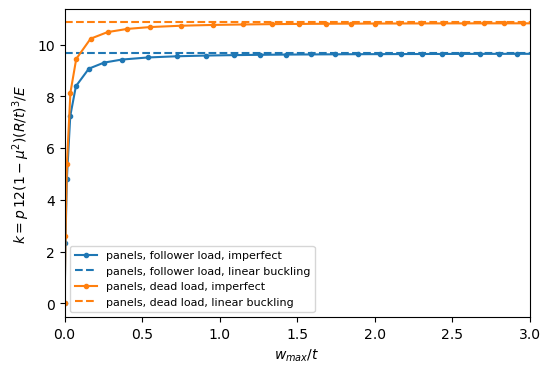

In [6]:
from structsolve import Analysis


def nonlinear(follower, eps=0.01):
    R, t, L = 100., 1., 600.
    E, MU = val.SCHWEIZERHOF_E, val.SCHWEIZERHOF_NU
    D = E*t**3/(12*(1 - MU**2))
    s = val.schweizerhof_sector(L, R, t, 3, 'B1')
    s.add_pressure_load(-1., cte=False, follower=follower)
    k0 = s.calc_kC()
    c0 = solve(k0, s.calc_fext(), silent=True)
    K = s.calc_kG(c=c0) + (s.calc_kCfollower() if follower else 0)
    ev, vecs = lb(k0, K, silent=True, num_eigvalues=4)
    lam_cr = float(np.real(ev[0]))
    phi = np.real(vecs[:, 0])
    phi *= t/np.abs(s.uvw(phi, gridx=15, gridy=9)[1]['w']).max()
    p0 = 1.2*lam_cr
    s.clear_loads()
    s.add_pressure_load(-p0, cte=False, follower=follower)
    f_imp = eps*p0/lam_cr*(k0 @ phi)

    def calc_fext(inc=1., silent=True, c=None):
        return s.calc_fext(inc=inc, silent=silent, c=c) + inc*f_imp

    an = Analysis(calc_fext, s.calc_fint, s.calc_kC, s.calc_kG)
    an.NL_method = 'arc_length_riks'
    an.initialInc = 0.2
    an.maxInc = 0.3
    an.maxArcLength = 8.
    an.relTOL = 1e-8
    an.static(NLgeom=True, silent=True)
    k = [lam*p0*R**3/D for lam in an.increments]
    w = [float(np.abs(s.uvw(c, gridx=15, gridy=9)[1]['w']).max()/t) for c in an.cs]
    return dict(k_lb=lam_cr*R**3/D, k=k, w=w)


nl = fu.run_or_load(os.path.join(RESULTS, 'schweizerhof1984_fig13.json'),
                    lambda: {'follower': nonlinear(True), 'dead': nonlinear(False)}, rerun=RERUN)
fig, ax = plt.subplots(figsize=(6, 4))
for key, st in (('follower', dict(color='C0')), ('dead', dict(color='C1'))):
    r = nl[key]
    ax.plot([0] + r['w'], [0] + r['k'], marker='.', label='panels, %s load, imperfect' % key, **st)
    ax.axhline(r['k_lb'], ls='--', label='panels, %s load, linear buckling' % key, **st)
ax.set_xlabel('$w_{max}/t$')
ax.set_ylabel('$k = p\\,12(1 - \\mu^2)(R/t)^3/E$')
ax.set_xlim(0, 3)
ax.legend(fontsize=8)
for key in ('follower', 'dead'):
    print('%s: linear buckling k = %.3f, nonlinear k at w/t = 1, 2: %s' % (
        key, nl[key]['k_lb'], np.interp([1., 2.], nl[key]['w'], nl[key]['k']).round(3)))

## Discussion

- **Table 2.** The load stiffness of panels is symmetric to round-off for the uniform pressure on the hinged shell, whose ends have $w = 0$, and unsymmetric for the free upper edge of the cantilever and for a non-uniform pressure, as Table 2 of the paper states for body-attached loads.
- **Table 3.** The three load behaviours give the analytical values of the paper, $k$ = 3, 4 and 4.5, to the extensibility of the ring, i.e. the follower load is 25% below the constant directional one and 33% below the centrally directed one; the FE solution of the paper for the centrally directed load is 1.6% low, which the paper attributes to an approximation of its load stiffness.
- **Table 4.** panels, the CLPT with Sanders' kinematics, is within 0.4% of the paper for every value of $k_c$ and $k_f$ of the hinged cylinders and of the cantilevers B1 and B2, except $k_c$ of the hinged shell 2, 1.1% above. For the cantilevers, the follower load lowers the critical pressure by 3% to 11%, and the unsymmetric solution of panels and the one with the symmetric part of the load stiffness only agree to the digits of the table, which is the observation of the paper that the nonconservative part of the load has a minor influence on the buckling of these shells.
- **B2, lower modes.** With the warping only restrained at one point, B2, panels finds lower loads with one circumferential wave less than the B1 sector adopted by the paper for B2, e.g. $n = 2$ for shell 1, with $k_c = 4.11$ and $k_f = 3.10$ against 9.11 and 8.10 for $n = 3$: the paper did not vary the sector for B2, so its values are not the lowest of this case.
- **Clamped.** The clamped cantilever is close to B1, the restrained rotation at the lower end adding little: $k_f$ of panels is 1.6% (shell 1) and 2.1% (shell 2) below the reference [36] of the paper and 5% to 8% below [15].
- **Fig. 13.** The load-deflection paths of the imperfect cantilever approach the linear buckling loads of the follower and of the constant directional pressures, which verifies the nonlinear follower terms of `calc_fint` and `calc_kT` against the load stiffness of the linear buckling analysis.